# Retail Analytics — Data Preparation & Customer Insights
## Project: Quantium Virtual Experience (Forage)
### Notebook: 01 — Load & Inspect Raw Data
### Tools: pandas
### Goal: Load transaction and customer datasets, examine shape, data types, nulls, and outliers before cleaning and merging.

# 1. Import libraries

In [2]:
import pandas as pd

# Show all columns when printing a DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('pandas version:', pd.__version__)

pandas version: 2.3.3


# 2. The openpyxl library is required under the hood for read_excel()

In [5]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


# 3. Load Datasets
## Two files from the data/ folder:
QVI_purchase_behaviour.csv (customer segments) and QVI_transaction_data.xlsx (transaction records)

In [6]:
import pandas as pd

DATA_PATH = '../data/'

customers     = pd.read_csv(DATA_PATH + 'QVI_purchase_behaviour.csv')
transactions  = pd.read_excel(DATA_PATH + 'QVI_transaction_data.xlsx')

print('Both datasets loaded.')
print(f'Customers:    {customers.shape}')
print(f'Transactions: {transactions.shape}')

Both datasets loaded.
Customers:    (72637, 3)
Transactions: (264836, 8)


# 4. Initial Inspection

In [7]:
print('=== CUSTOMERS ===')
print(customers.head())
print(customers.dtypes)
print(customers.isnull().sum())

print('\n=== TRANSACTIONS ===')
print(transactions.head())
print(transactions.dtypes)
print(transactions.isnull().sum())

=== CUSTOMERS ===
   LYLTY_CARD_NBR               LIFESTAGE PREMIUM_CUSTOMER
0            1000   YOUNG SINGLES/COUPLES          Premium
1            1002   YOUNG SINGLES/COUPLES       Mainstream
2            1003          YOUNG FAMILIES           Budget
3            1004   OLDER SINGLES/COUPLES       Mainstream
4            1005  MIDAGE SINGLES/COUPLES       Mainstream
LYLTY_CARD_NBR       int64
LIFESTAGE           object
PREMIUM_CUSTOMER    object
dtype: object
LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

=== TRANSACTIONS ===
    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  
0    Natural Chip     

# 5. Fix DATE column (Excel serial → proper datetime) and Clean extra space

In [8]:
transactions['DATE'] = pd.to_datetime(transactions['DATE'], origin='1899-12-30', unit='D')

# Clean extra whitespace in PROD_NAME
transactions['PROD_NAME'] = transactions['PROD_NAME'].str.strip().str.replace(r'\s+', ' ', regex=True)

print(transactions[['DATE', 'PROD_NAME', 'PROD_QTY', 'TOT_SALES']].head())
print(transactions['DATE'].dtype)

        DATE                                 PROD_NAME  PROD_QTY  TOT_SALES
0 2018-10-17           Natural Chip Compny SeaSalt175g         2       6.00
1 2019-05-14                     CCs Nacho Cheese 175g         3       6.30
2 2019-05-20     Smiths Crinkle Cut Chips Chicken 170g         2       2.90
3 2018-08-17     Smiths Chip Thinly S/Cream&Onion 175g         5      15.00
4 2018-08-18  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3      13.80
datetime64[ns]


# 6. Outlier Check

In [9]:
print('=== PROD_QTY ===')
print(transactions['PROD_QTY'].describe())
print('\nTop 10 highest PROD_QTY:')
print(transactions.nlargest(10, 'PROD_QTY')[['DATE', 'LYLTY_CARD_NBR', 'PROD_NAME', 'PROD_QTY', 'TOT_SALES']])

print('\n=== TOT_SALES ===')
print(transactions['TOT_SALES'].describe())
print('\nTop 10 highest TOT_SALES:')
print(transactions.nlargest(10, 'TOT_SALES')[['DATE', 'LYLTY_CARD_NBR', 'PROD_NAME', 'PROD_QTY', 'TOT_SALES']])

=== PROD_QTY ===
count   264,836.00
mean          1.91
std           0.64
min           1.00
25%           2.00
50%           2.00
75%           2.00
max         200.00
Name: PROD_QTY, dtype: float64

Top 10 highest PROD_QTY:
            DATE  LYLTY_CARD_NBR                               PROD_NAME  \
69762 2018-08-19          226000            Dorito Corn Chp Supreme 380g   
69763 2019-05-20          226000            Dorito Corn Chp Supreme 380g   
3     2018-08-17            2373   Smiths Chip Thinly S/Cream&Onion 175g   
11    2018-08-20            8294     Kettle Sensations Siracha Lime 150g   
56    2019-05-16           74336   GrnWves Plus Btroot & Chilli Jam 180g   
72    2018-08-19           96203            Smiths Crinkle Original 330g   
74    2018-08-16           97159              Woolworths Mild Salsa 300g   
100   2019-05-20          130108   Cobs Popd Sour Crm &Chives Chips 110g   
115   2018-08-19          160136     Smith Crinkle Cut Mac N Cheese 150g   
137   2018-08-

# 7. Remove outlier customer 226000 (bulk buyer — 200 units twice, not retail behaviour)

In [10]:
print(f'Rows before: {len(transactions)}')

transactions = transactions[transactions['LYLTY_CARD_NBR'] != 226000]

print(f'Rows after:  {len(transactions)}')
print(f'Rows removed: {264836 - len(transactions)}')

Rows before: 264836
Rows after:  264834
Rows removed: 2


# 8. Check for non-chip items in PROD_NAME
Salsa dips sometimes sneak into chip category data

In [11]:
print(transactions['PROD_NAME'].unique())

['Natural Chip Compny SeaSalt175g' 'CCs Nacho Cheese 175g'
 'Smiths Crinkle Cut Chips Chicken 170g'
 'Smiths Chip Thinly S/Cream&Onion 175g'
 'Kettle Tortilla ChpsHny&Jlpno Chili 150g'
 'Old El Paso Salsa Dip Tomato Mild 300g'
 'Smiths Crinkle Chips Salt & Vinegar 330g'
 'Grain Waves Sweet Chilli 210g' 'Doritos Corn Chip Mexican Jalapeno 150g'
 'Grain Waves Sour Cream&Chives 210G'
 'Kettle Sensations Siracha Lime 150g' 'Twisties Cheese 270g'
 'WW Crinkle Cut Chicken 175g' 'Thins Chips Light& Tangy 175g'
 'CCs Original 175g' 'Burger Rings 220g'
 'NCC Sour Cream & Garden Chives 175g'
 'Doritos Corn Chip Southern Chicken 150g' 'Cheezels Cheese Box 125g'
 'Smiths Crinkle Original 330g' 'Infzns Crn Crnchers Tangy Gcamole 110g'
 'Kettle Sea Salt And Vinegar 175g' 'Smiths Chip Thinly Cut Original 175g'
 'Kettle Original 175g' 'Red Rock Deli Thai Chilli&Lime 150g'
 'Pringles Sthrn FriedChicken 134g' 'Pringles Sweet&Spcy BBQ 134g'
 'Red Rock Deli SR Salsa & Mzzrlla 150g' 'Thins Chips Originl sa

# 9. Remove non-chip products (salsa dips)

In [12]:
salsa_mask = transactions['PROD_NAME'].str.contains('Salsa|Dip', case=False, regex=True)

print(f'Non-chip rows to remove: {salsa_mask.sum()}')
transactions = transactions[~salsa_mask]
print(f'Rows remaining: {len(transactions)}')

Non-chip rows to remove: 19532
Rows remaining: 245302


# 10. Feature Engineering — Extract pack size and brand name

In [13]:
# Extract pack size (e.g. 175g, 134g) from PROD_NAME
transactions['PACK_SIZE'] = transactions['PROD_NAME'].str.extract(r'(\d+[gG])')
transactions['PACK_SIZE'] = transactions['PACK_SIZE'].str.upper()

# Extract brand name (first word of PROD_NAME)
transactions['BRAND'] = transactions['PROD_NAME'].str.split().str[0]

print(transactions[['PROD_NAME', 'PACK_SIZE', 'BRAND']].head(10))
print('\nUnique pack sizes:')
print(sorted(transactions['PACK_SIZE'].unique()))
print('\nUnique brands:')
print(sorted(transactions['BRAND'].unique()))

                                   PROD_NAME PACK_SIZE    BRAND
0            Natural Chip Compny SeaSalt175g      175G  Natural
1                      CCs Nacho Cheese 175g      175G      CCs
2      Smiths Crinkle Cut Chips Chicken 170g      170G   Smiths
3      Smiths Chip Thinly S/Cream&Onion 175g      175G   Smiths
4   Kettle Tortilla ChpsHny&Jlpno Chili 150g      150G   Kettle
6   Smiths Crinkle Chips Salt & Vinegar 330g      330G   Smiths
7              Grain Waves Sweet Chilli 210g      210G    Grain
8    Doritos Corn Chip Mexican Jalapeno 150g      150G  Doritos
9         Grain Waves Sour Cream&Chives 210G      210G    Grain
10  Smiths Crinkle Chips Salt & Vinegar 330g      330G   Smiths

Unique pack sizes:
['110G', '125G', '134G', '135G', '150G', '160G', '165G', '170G', '175G', '180G', '190G', '200G', '210G', '220G', '250G', '270G', '330G', '380G', '70G', '90G']

Unique brands:
['Burger', 'CCs', 'Cheetos', 'Cheezels', 'Cobs', 'Dorito', 'Doritos', 'French', 'Grain', 'GrnWves', '

# 11. Standardise brand names

In [14]:
brand_map = {
    'Dorito'  : 'Doritos',
    'Smith'   : 'Smiths',
    'Grain'   : 'Grain Waves',
    'GrnWves' : 'Grain Waves',
    'Red'     : 'Red Rock Deli',
    'RRD'     : 'Red Rock Deli',
    'Infzns'  : 'Infuzions',
    'Snbts'   : 'Sunbites',
    'NCC'     : 'Natural',
    'WW'      : 'Woolworths',
}

transactions['BRAND'] = transactions['BRAND'].replace(brand_map)

print(sorted(transactions['BRAND'].unique()))

['Burger', 'CCs', 'Cheetos', 'Cheezels', 'Cobs', 'Doritos', 'French', 'Grain Waves', 'Infuzions', 'Kettle', 'Natural', 'Pringles', 'Red Rock Deli', 'Smiths', 'Sunbites', 'Thins', 'Tostitos', 'Twisties', 'Tyrrells', 'Woolworths']


# 12. Merge transactions with customer data on LYLTY_CARD_NBR

In [15]:
merged = transactions.merge(customers, on='LYLTY_CARD_NBR', how='left')

print(f'Merged shape: {merged.shape}')
print(f'Nulls after merge:\n{merged.isnull().sum()}')
print(merged.head())

Merged shape: (245302, 12)
Nulls after merge:
DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64
        DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0 2018-10-17          1            1000       1         5   
1 2019-05-14          1            1307     348        66   
2 2019-05-20          1            1343     383        61   
3 2018-08-17          2            2373     974        69   
4 2018-08-18          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES PACK_SIZE  \
0           Natural Chip Compny SeaSalt175g         2       6.00      175G   
1                     CCs Nacho Cheese 175g         3       6.30      175G   
2     Smiths Crinkle Cut Chips Chicken 170g         2       2.90      170G  

# 13. Save cleaned merged dataset

In [16]:
merged.to_csv('../data/QVI_data_clean.csv', index=False)
print('Cleaned dataset saved to data/QVI_data_clean.csv')

Cleaned dataset saved to data/QVI_data_clean.csv


# ───────────── TASK 1 ANALYSIS ───────────────
# 14. Define metrics of interest

In [17]:
# - Total sales revenue
# - Number of customers
# - Average transactions per customer
# - Average spend per customer
# - Sales by LIFESTAGE and PREMIUM_CUSTOMER segment

total_sales = merged['TOT_SALES'].sum()
total_customers = merged['LYLTY_CARD_NBR'].nunique()
total_transactions = merged['TXN_ID'].nunique()
avg_spend_per_customer = total_sales / total_customers
avg_txn_per_customer = total_transactions / total_customers

print(f'Total Sales Revenue:        ${total_sales:,.2f}')
print(f'Total Unique Customers:      {total_customers:,}')
print(f'Total Transactions:          {total_transactions:,}')
print(f'Avg Spend per Customer:     ${avg_spend_per_customer:,.2f}')
print(f'Avg Transactions per Customer: {avg_txn_per_customer:.2f}')

Total Sales Revenue:        $1,798,131.70
Total Unique Customers:      71,185
Total Transactions:          243,838
Avg Spend per Customer:     $25.26
Avg Transactions per Customer: 3.43


# 15. Sales by LIFESTAGE and PREMIUM_CUSTOMER segment

             LIFESTAGE PREMIUM_CUSTOMER  TOT_SALES
        OLDER FAMILIES           Budget 156,096.75
 YOUNG SINGLES/COUPLES       Mainstream 147,244.20
              RETIREES       Mainstream 144,677.55
        YOUNG FAMILIES           Budget 129,151.15
 OLDER SINGLES/COUPLES           Budget 127,279.80
 OLDER SINGLES/COUPLES       Mainstream 124,089.50
 OLDER SINGLES/COUPLES          Premium 123,147.55
              RETIREES           Budget 105,586.10
        OLDER FAMILIES       Mainstream  96,059.95
              RETIREES          Premium  91,013.25
        YOUNG FAMILIES       Mainstream  85,919.65
MIDAGE SINGLES/COUPLES       Mainstream  84,500.25
        YOUNG FAMILIES          Premium  78,176.50
        OLDER FAMILIES          Premium  74,899.40
 YOUNG SINGLES/COUPLES           Budget  56,807.50
MIDAGE SINGLES/COUPLES          Premium  54,254.05
 YOUNG SINGLES/COUPLES          Premium  38,875.50
MIDAGE SINGLES/COUPLES           Budget  33,150.70
          NEW FAMILIES         

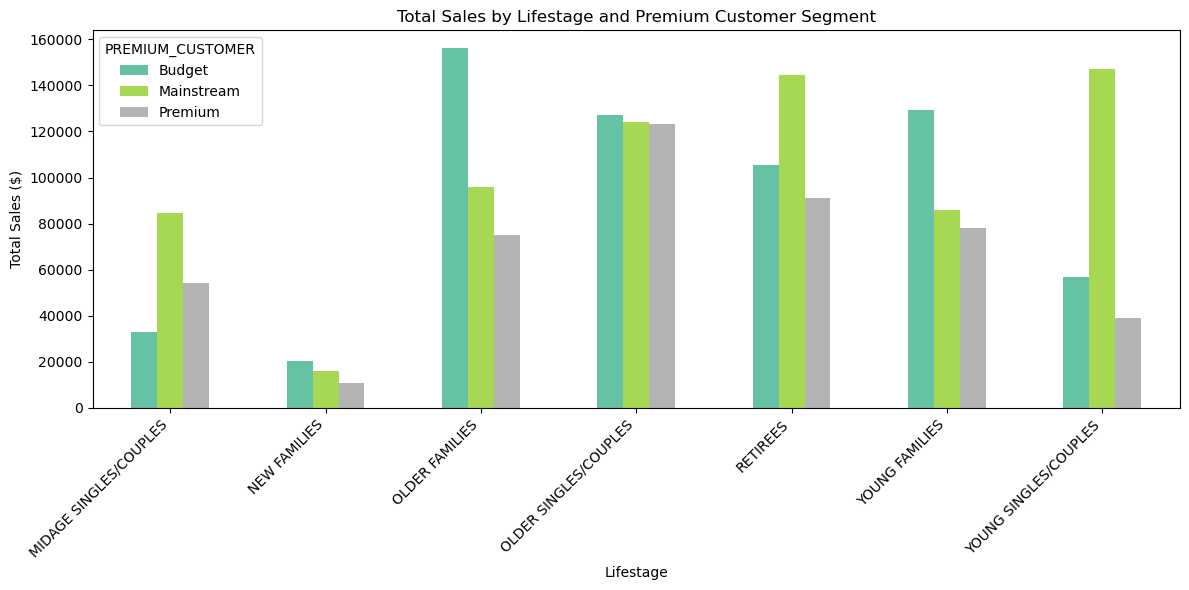

Chart saved to outputs/


In [18]:
import matplotlib.pyplot as plt

segment_sales = merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
segment_sales = segment_sales.sort_values('TOT_SALES', ascending=False)

print(segment_sales.to_string(index=False))

# Visualise
pivot = segment_sales.pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='TOT_SALES')

pivot.plot(kind='bar', figsize=(12, 6), colormap='Set2')
plt.title('Total Sales by Lifestage and Premium Customer Segment')
plt.ylabel('Total Sales ($)')
plt.xlabel('Lifestage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/sales_by_segment.png', dpi=150)
plt.show()
print('Chart saved to outputs/')

# 16. Customers and avg spend per segment

In [19]:
segment_stats = merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg(
    total_sales    = ('TOT_SALES', 'sum'),
    num_customers  = ('LYLTY_CARD_NBR', 'nunique'),
    num_txns       = ('TXN_ID', 'nunique')
).reset_index()

segment_stats['avg_spend_per_customer'] = segment_stats['total_sales'] / segment_stats['num_customers']
segment_stats['avg_txns_per_customer']  = segment_stats['num_txns'] / segment_stats['num_customers']

segment_stats = segment_stats.sort_values('avg_spend_per_customer', ascending=False)
print(segment_stats.to_string(index=False))

             LIFESTAGE PREMIUM_CUSTOMER  total_sales  num_customers  num_txns  avg_spend_per_customer  avg_txns_per_customer
        OLDER FAMILIES       Mainstream    96,059.95           2782     13059                   34.53                   4.69
        OLDER FAMILIES           Budget   156,096.75           4606     21173                   33.89                   4.60
        OLDER FAMILIES          Premium    74,899.40           2229     10234                   33.60                   4.59
        YOUNG FAMILIES           Budget   129,151.15           3951     17517                   32.69                   4.43
        YOUNG FAMILIES          Premium    78,176.50           2397     10625                   32.61                   4.43
        YOUNG FAMILIES       Mainstream    85,919.65           2683     11779                   32.02                   4.39
 OLDER SINGLES/COUPLES          Premium   123,147.55           4679     16394                   26.32                   3.50


# 17. Top brands by segment (focus on top 3 segments by avg spend)

In [20]:
top_segments = ['OLDER FAMILIES', 'YOUNG FAMILIES']

top_seg_data = merged[merged['LIFESTAGE'].isin(top_segments)]

brand_preference = top_seg_data.groupby(['LIFESTAGE', 'BRAND'])['TOT_SALES'].sum().reset_index()
brand_preference = brand_preference.sort_values(['LIFESTAGE', 'TOT_SALES'], ascending=[True, False])

# Top 5 brands per lifestage
top_brands = brand_preference.groupby('LIFESTAGE').head(5)
print(top_brands.to_string(index=False))

     LIFESTAGE         BRAND  TOT_SALES
OLDER FAMILIES        Kettle  65,984.00
OLDER FAMILIES        Smiths  42,089.30
OLDER FAMILIES       Doritos  38,533.90
OLDER FAMILIES      Pringles  30,584.20
OLDER FAMILIES Red Rock Deli  19,868.70
YOUNG FAMILIES        Kettle  60,033.00
YOUNG FAMILIES        Smiths  36,870.70
YOUNG FAMILIES       Doritos  35,248.50
YOUNG FAMILIES      Pringles  27,498.40
YOUNG FAMILIES Red Rock Deli  17,316.00


# 18. Pack size preference by family segments

In [21]:
packsize_pref = top_seg_data.groupby(['LIFESTAGE', 'PACK_SIZE'])['TOT_SALES'].sum().reset_index()
packsize_pref = packsize_pref.sort_values(['LIFESTAGE', 'TOT_SALES'], ascending=[True, False])

top_packsizes = packsize_pref.groupby('LIFESTAGE').head(5)
print(top_packsizes.to_string(index=False))

     LIFESTAGE PACK_SIZE  TOT_SALES
OLDER FAMILIES      175G  88,563.50
OLDER FAMILIES      150G  51,655.40
OLDER FAMILIES      134G  30,584.20
OLDER FAMILIES      110G  28,123.80
OLDER FAMILIES      170G  26,886.90
YOUNG FAMILIES      175G  80,213.60
YOUNG FAMILIES      150G  46,164.70
YOUNG FAMILIES      134G  27,498.40
YOUNG FAMILIES      110G  25,414.40
YOUNG FAMILIES      170G  24,417.40


# 19. Brand and pack size preference — Young Singles/Couples Mainstream

In [22]:
ysc_mainstream = merged[
    (merged['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & 
    (merged['PREMIUM_CUSTOMER'] == 'Mainstream')
]

print('=== TOP BRANDS ===')
ysc_brands = ysc_mainstream.groupby('BRAND')['TOT_SALES'].sum().sort_values(ascending=False).head(5)
print(ysc_brands)

print('\n=== TOP PACK SIZES ===')
ysc_packs = ysc_mainstream.groupby('PACK_SIZE')['TOT_SALES'].sum().sort_values(ascending=False).head(5)
print(ysc_packs)

=== TOP BRANDS ===
BRAND
Kettle      35,423.60
Doritos     20,925.90
Pringles    16,006.20
Smiths      14,620.90
Infuzions    8,749.40
Name: TOT_SALES, dtype: float64

=== TOP PACK SIZES ===
PACK_SIZE
175G   37,967.90
150G   22,608.20
134G   16,006.20
110G   14,630.00
330G   12,654.00
Name: TOT_SALES, dtype: float64


# 20a. Visualise avg spend per customer by segment

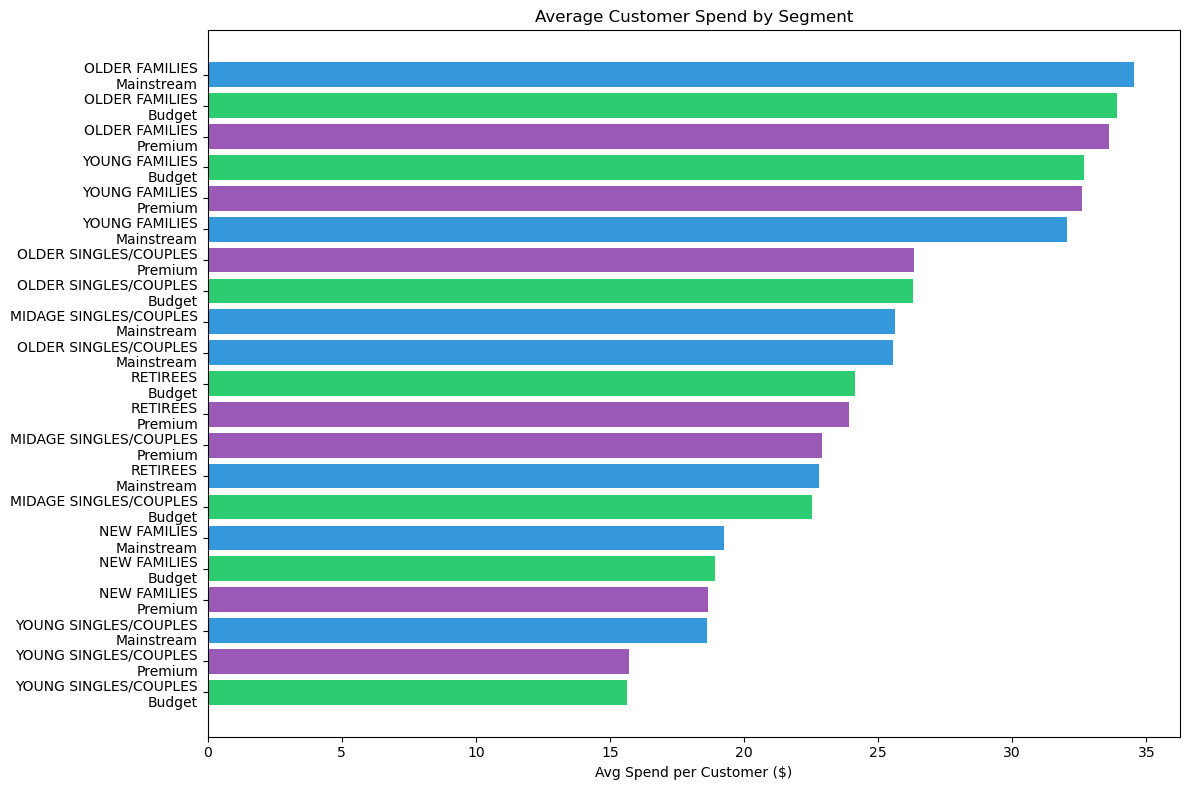

Chart saved to outputs/


In [23]:
import matplotlib.pyplot as plt

segment_stats['segment'] = segment_stats['LIFESTAGE'] + '\n' + segment_stats['PREMIUM_CUSTOMER']
segment_stats_sorted = segment_stats.sort_values('avg_spend_per_customer', ascending=True)

plt.figure(figsize=(12, 8))
colors = segment_stats_sorted['PREMIUM_CUSTOMER'].map({
    'Budget'     : '#2ecc71',
    'Mainstream' : '#3498db',
    'Premium'    : '#9b59b6'
})

plt.barh(segment_stats_sorted['segment'], segment_stats_sorted['avg_spend_per_customer'], color=colors)
plt.xlabel('Avg Spend per Customer ($)')
plt.title('Average Customer Spend by Segment')
plt.tight_layout()
plt.savefig('../outputs/avg_spend_by_segment.png', dpi=150)
plt.show()
print('Chart saved to outputs/')

# 20b. Fix segment labels — combine on one line

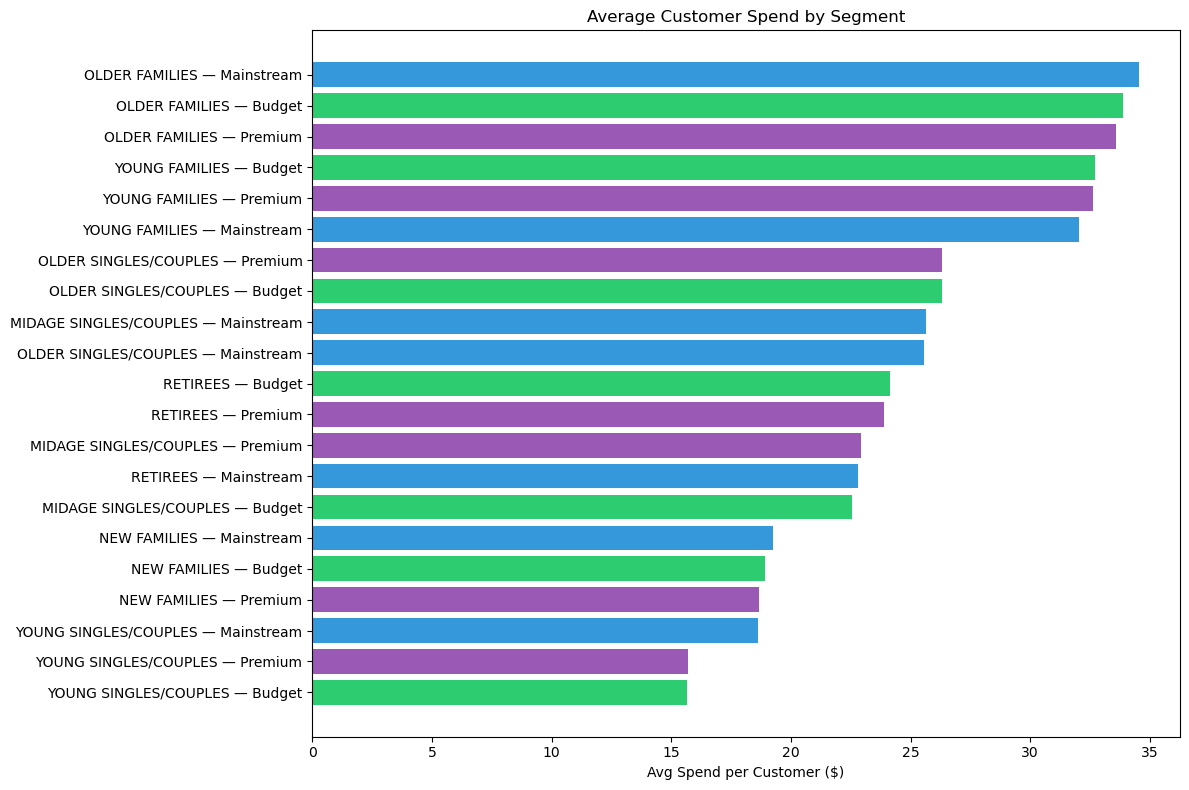

In [24]:
segment_stats['segment'] = segment_stats['LIFESTAGE'] + ' — ' + segment_stats['PREMIUM_CUSTOMER']
segment_stats_sorted = segment_stats.sort_values('avg_spend_per_customer', ascending=True)

plt.figure(figsize=(12, 8))
colors = segment_stats_sorted['PREMIUM_CUSTOMER'].map({
    'Budget'     : '#2ecc71',
    'Mainstream' : '#3498db',
    'Premium'    : '#9b59b6'
})

plt.barh(segment_stats_sorted['segment'], segment_stats_sorted['avg_spend_per_customer'], color=colors)
plt.xlabel('Avg Spend per Customer ($)')
plt.title('Average Customer Spend by Segment')
plt.tight_layout()
plt.savefig('../outputs/avg_spend_by_segment.png', dpi=150)
plt.show()

# ────────── FINDINGS & RECOMMENDATIONS ──────────


# Key Findings & Recommendations

## Overall Performance

* Total chip sales: \$1.80M  
* Unique customers: 71,185  
* Average spend per customer: \$25.26  
* Average transactions per customer: 3.43  

## Highest-Spending Customer Segments

Families are the strongest customer group on a per-customer basis:

* Older Families (Mainstream): \$34.53 average spend per customer  
* Older Families (Budget): \$33.89  
* Young Families (Budget): \$32.69  

In contrast, Young Singles/Couples Mainstream generate strong total sales of 147K, primarily because of their large customer base of 7,908 customers, despite spending only 18.62 per customer — one of the lowest averages among established segments.

## Brand Preferences

* Kettle is the leading brand across all major customer segments.  
* Family segments favour: Kettle → Smiths → Doritos → Pringles → Red Rock Deli  
* Young Singles/Couples favour: Kettle → Doritos → Pringles → Smiths → Infuzions  
* Infuzions appears only in the Young Singles/Couples top five brands, suggesting differentiated preferences within this segment.  

## Pack Size Preferences

* 175g is the most popular pack size across all major segments.  
* Family segments show particularly strong demand for 175g and 150g packs.  
* Young Singles/Couples demonstrate relatively higher purchases of 330g packs compared with other segments, potentially reflecting group-consumption occasions.  

## Recommendations

1. Prioritise Older and Young Families
    * Highest average spend per customer.
    * Strong purchase frequency (4.4–4.7 transactions per customer).
    * Consistent preference for Kettle and Smiths.
    * Focus promotions and shelf visibility on popular 175g and 150g family-sized packs.
2. Retain Retirees and Older Singles/Couples
    * Moderate average spend (approximately 24 to 26 per customer).
    * Large customer base with reliable repeat purchasing behaviour.
    * Suitable audience for loyalty and retention campaigns.
3. Grow Young Singles/Couples Mainstream
    * Large customer segment driving significant revenue volume.
    * Strong affinity for Doritos and Infuzions compared with family segments.
    * Consider targeted promotions and larger-pack offers to increase basket size.
4. Lower Priority: New Families
    * Lowest spend and transaction frequency across customer groups.
    * Allocate investment selectively while focusing resources on higher-value segments.
